<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/lab10/Lab10_FRED_Causality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr

In [31]:

start = "2010-01-01"
end = "2024-12-31"

series = {
    "CPIAUCSL": "cpi",
    "UNRATE": "unrate",
    "FEDFUNDS": "fedfunds",
    "INDPRO": "indpro",
    "RSAFS": "retail_sales",
    "DGS10": "dgs10",
    "PAYEMS": "payrolls",
    "M2SL": "m2"
}

df_list = []
for fred_code, col_name in series.items():
    s = pdr.DataReader(fred_code, "fred", start, end)
    s.columns = [col_name]
    df_list.append(s)

df = pd.concat(df_list, axis=1)

df = df.resample("MS").mean()

df = df.dropna().copy()
print("Shape:", df.shape)
display(df.head())
display(df.tail())


Shape: (180, 8)


,cpi,unrate,fedfunds,indpro,retail_sales,dgs10,payrolls,m2
DATE,,,,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,339093.0,3.733158,129802.0,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,339580.0,3.691053,129706.0,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,346974.0,3.727391,129866.0,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,349869.0,3.846818,130120.0,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,346858.0,3.420000,130642.0,8609.0


,cpi,unrate,fedfunds,indpro,retail_sales,dgs10,payrolls,m2
DATE,,,,,,,,
2024-08-01,314.062,4.2,5.33,100.4309,697039.0,3.870909,157757.0,21204.7
2024-09-01,314.732,4.1,5.13,99.8084,703055.0,3.723500,157912.0,21289.0
2024-10-01,315.631,4.1,4.83,99.4695,708290.0,4.095455,157945.0,21337.0
2024-11-01,316.528,4.2,4.64,99.2925,711853.0,4.355789,158079.0,21440.0
2024-12-01,317.604,4.1,4.48,100.3273,717547.0,4.391429,158316.0,21458.4


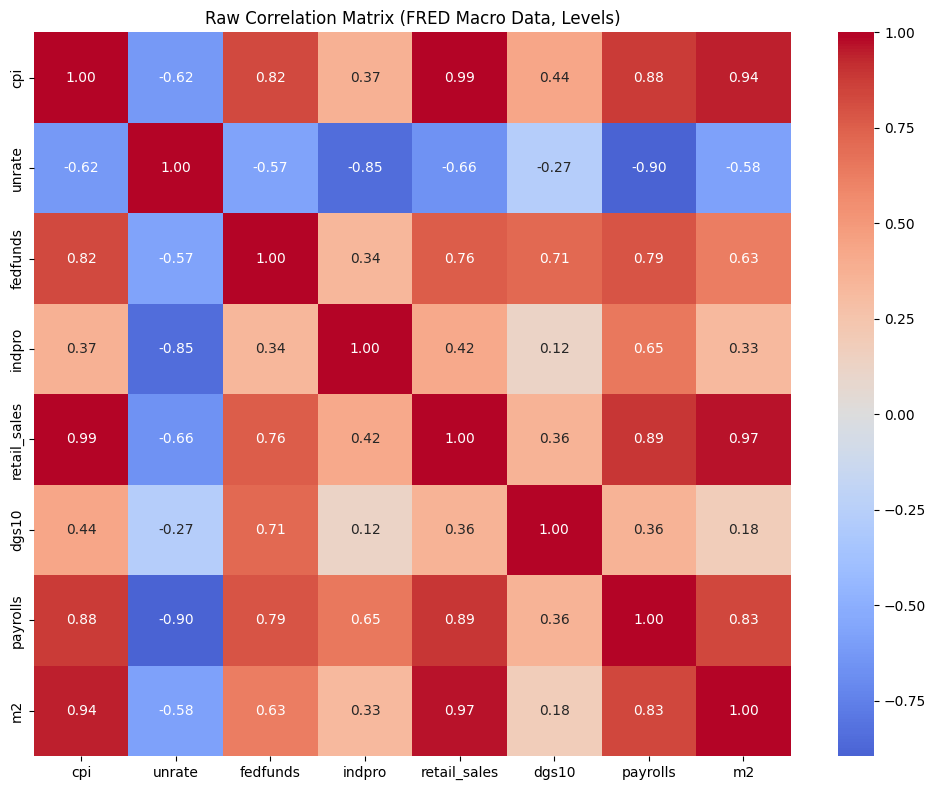

,cpi,unrate,fedfunds,indpro,retail_sales,dgs10,payrolls,m2
cpi,1.000000,-0.623474,0.823073,0.369407,0.986267,0.435142,0.880069,0.944626
unrate,-0.623474,1.000000,-0.571440,-0.845866,-0.664951,-0.270130,-0.895027,-0.583430
fedfunds,0.823073,-0.571440,1.000000,0.339562,0.756715,0.712378,0.788953,0.625806
indpro,0.369407,-0.845866,0.339562,1.000000,0.416271,0.124720,0.650075,0.325999
retail_sales,0.986267,-0.664951,0.756715,0.416271,1.000000,0.362096,0.889437,0.970290
dgs10,0.435142,-0.270130,0.712378,0.124720,0.362096,1.000000,0.357583,0.181830
payrolls,0.880069,-0.895027,0.788953,0.650075,0.889437,0.357583,1.000000,0.829877
m2,0.944626,-0.583430,0.625806,0.325999,0.970290,0.181830,0.829877,1.000000


In [32]:
corr_raw = df.corr(numeric_only=True)



plt.figure(figsize=(10, 8))
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Raw Correlation Matrix (FRED Macro Data, Levels)")
plt.tight_layout()
plt.show()

corr_raw

In [33]:
y = df["cpi"]
X = df[["unrate", "fedfunds", "indpro", "retail_sales", "dgs10", "payrolls", "m2"]]
X = sm.add_constant(X, has_constant="add")
naive_model = sm.OLS(y, X, missing="drop").fit()
print(naive_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     2876.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          1.36e-174
Time:                        20:33:40   Log-Likelihood:                -428.25
No. Observations:                 180   AIC:                             872.5
Df Residuals:                     172   BIC:                             898.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -11.6769     35.419     -0.330   

In [34]:
def compute_vif(X_df: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF for each column in a design matrix (including constant if provided)."""
    vif_df = pd.DataFrame({
        "feature": X_df.columns,
        "VIF": [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
    })
    return vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

X_vif = df[["unrate", "fedfunds", "indpro", "retail_sales", "dgs10", "payrolls", "m2"]].copy()
X_vif_const = sm.add_constant(X_vif, has_constant="add")
vif_initial = compute_vif(X_vif_const)
display(vif_initial)

,feature,VIF
0,const,31621.445472
1,retail_sales,91.249371
2,m2,84.212750
3,payrolls,73.664945
4,unrate,32.428368
5,fedfunds,16.454093
6,indpro,5.080778
7,dgs10,4.311314


In [35]:
def iterative_vif_reduction(X_df: pd.DataFrame, threshold: float = 10.0, verbose: bool = True):
    """
    Iteratively drop the highest-VIF non-constant variable until all remaining VIFs are <= threshold.
    Returns:
        kept_X, history (list of dicts), final_vif
    """
    current = X_df.copy()
    history = []

    while True:
        X_const = sm.add_constant(current, has_constant="add")
        vif_table = compute_vif(X_const)

        # Exclude constant when checking stopping condition
        vif_nonconst = vif_table[vif_table["feature"] != "const"].copy()
        max_row = vif_nonconst.iloc[0]
        max_feature = max_row["feature"]
        max_vif = float(max_row["VIF"])

        if verbose:
            print("\nCurrent VIF table:")
            display(vif_table)
            print(f"Max non-constant VIF: {max_feature} = {max_vif:.2f}")

        if max_vif <= threshold:
            final_vif = vif_table
            break

        history.append({"dropped": max_feature, "vif": max_vif})
        current = current.drop(columns=[max_feature])
        if verbose:
            print(f"--> Dropping '{max_feature}' and recomputing...")

    return current, history, final_vif

X_candidates = df[["unrate", "fedfunds", "indpro", "retail_sales", "dgs10", "payrolls", "m2"]].copy()
X_reduced, vif_drop_history, vif_final = iterative_vif_reduction(X_candidates, threshold=10.0, verbose=False)

print("Variables dropped (in order):")
for step in vif_drop_history:
    print(f" - {step['dropped']} (VIF={step['vif']:.2f})")

print("\nRemaining variables:")
print(list(X_reduced.columns))

print("\nFinal VIF table:")
display(vif_final)

Variables dropped (in order):
 - retail_sales (VIF=91.25)
 - payrolls (VIF=70.18)

Remaining variables:
['unrate', 'fedfunds', 'indpro', 'dgs10', 'm2']

Final VIF table:


,feature,VIF
0,const,4617.322802
1,unrate,6.291840
2,fedfunds,4.549051
3,indpro,4.328142
4,dgs10,2.687299
5,m2,2.547671


In [36]:
X_reduced_const = sm.add_constant(X_reduced, has_constant="add")
vif_clean_model = sm.OLS(df["cpi"], X_reduced_const, missing="drop").fit()

print(vif_clean_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     2375.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          4.68e-158
Time:                        20:33:40   Log-Likelihood:                -476.24
No. Observations:                 180   AIC:                             964.5
Df Residuals:                     174   BIC:                             983.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         95.9610     17.569      5.462      0.0

In [37]:
df_t = df.copy()

for col in ["cpi", "payrolls", "retail_sales", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

df_t["inflation_yoy"] = df_t["cpi_yoy"]


use_cols = [
    "inflation_yoy", "unrate", "fedfunds", "dgs10",
    "indpro_yoy", "retail_sales_yoy", "payrolls_yoy", "m2_yoy"
]

df_t = df_t[use_cols].copy()

print("Transformed dataset shape:", df_t.shape)
display(df_t.head())

Transformed dataset shape: (180, 8)


,inflation_yoy,unrate,fedfunds,dgs10,indpro_yoy,retail_sales_yoy,payrolls_yoy,m2_yoy
DATE,,,,,,,,
2010-01-01,NaN,9.8,0.11,3.733158,NaN,NaN,NaN,NaN
2010-02-01,NaN,9.8,0.13,3.691053,NaN,NaN,NaN,NaN
2010-03-01,NaN,9.9,0.16,3.727391,NaN,NaN,NaN,NaN
2010-04-01,NaN,9.9,0.20,3.846818,NaN,NaN,NaN,NaN
2010-05-01,NaN,9.6,0.20,3.420000,NaN,NaN,NaN,NaN


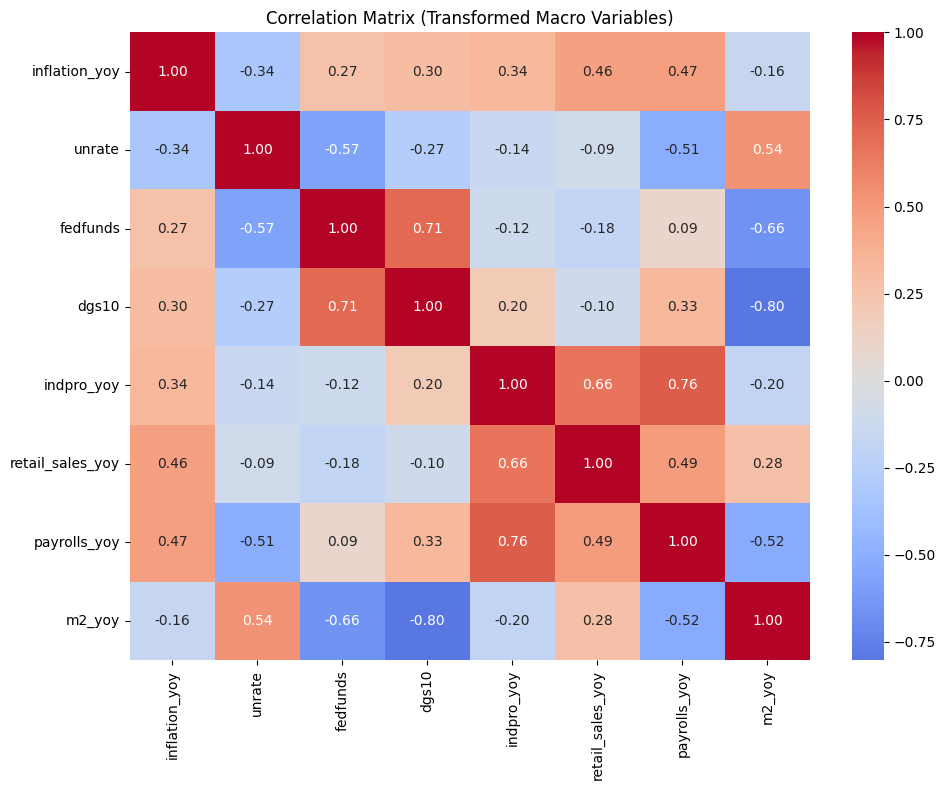

,inflation_yoy,unrate,fedfunds,dgs10,indpro_yoy,retail_sales_yoy,payrolls_yoy,m2_yoy
inflation_yoy,1.000000,-0.336635,0.269474,0.302465,0.337452,0.461802,0.467647,-0.156794
unrate,-0.336635,1.000000,-0.571440,-0.270130,-0.141887,-0.091587,-0.511403,0.535113
fedfunds,0.269474,-0.571440,1.000000,0.712378,-0.116622,-0.184188,0.093490,-0.657521
dgs10,0.302465,-0.270130,0.712378,1.000000,0.200128,-0.099132,0.325223,-0.802162
indpro_yoy,0.337452,-0.141887,-0.116622,0.200128,1.000000,0.663962,0.759340,-0.195377
retail_sales_yoy,0.461802,-0.091587,-0.184188,-0.099132,0.663962,1.000000,0.487946,0.277839
payrolls_yoy,0.467647,-0.511403,0.093490,0.325223,0.759340,0.487946,1.000000,-0.521663
m2_yoy,-0.156794,0.535113,-0.657521,-0.802162,-0.195377,0.277839,-0.521663,1.000000


In [38]:
corr_transformed = df_t.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_transformed, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Transformed Macro Variables)")
plt.tight_layout()
plt.show()

corr_transformed

In [39]:
y2 = df_t["inflation_yoy"]
X2 = df_t[["unrate", "fedfunds", "dgs10", "indpro_yoy", "retail_sales_yoy", "payrolls_yoy", "m2_yoy"]]
X2 = sm.add_constant(X2, has_constant="add")

model_transformed = sm.OLS(y2, X2, missing="drop").fit()
print(model_transformed.summary())

                            OLS Regression Results                            
Dep. Variable:          inflation_yoy   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     20.71
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.13e-19
Time:                        20:33:41   Log-Likelihood:                -300.89
No. Observations:                 168   AIC:                             617.8
Df Residuals:                     160   BIC:                             642.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.8806      1.145  

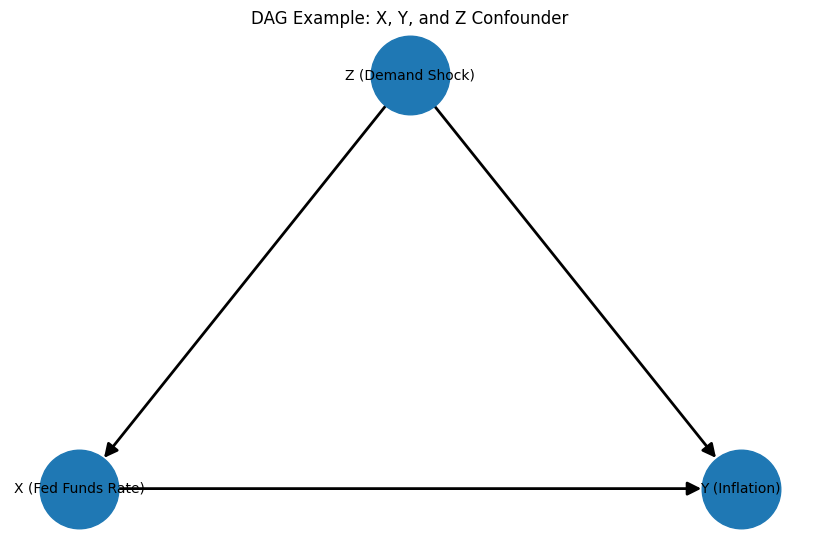

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# X = policy rate, Y = inflation, Z = confounder
G.add_edges_from([
    ("Z (Demand Shock)", "X (Fed Funds Rate)"),
    ("Z (Demand Shock)", "Y (Inflation)"),
    ("X (Fed Funds Rate)", "Y (Inflation)")  # optional direct causal path
])

pos = {
    "Z (Demand Shock)": (0, 1),
    "X (Fed Funds Rate)": (-1, 0),
    "Y (Inflation)": (1, 0)
}

plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_size=3200, font_size=10,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    width=2
)
plt.title("DAG Example: X, Y, and Z Confounder")
plt.axis("off")
plt.show()

In [41]:

extra_series = {
    "DCOILWTICO": "wti_oil_daily"
}

extra_df_list = []
for fred_code, col_name in extra_series.items():
    try:
        s = pdr.DataReader(fred_code, "fred", start, end)
        s.columns = [col_name]
        extra_df_list.append(s)
        print(f"Loaded {fred_code} -> {col_name}")
    except Exception as e:
        print(f"Could not load {fred_code}: {e}")

if extra_df_list:
    df_extra = pd.concat(extra_df_list, axis=1).resample("MS").mean()
    df_ext = df.join(df_extra, how="left")
    display(df_ext.tail())
else:
    df_ext = df.copy()

Loaded DCOILWTICO -> wti_oil_daily


,cpi,unrate,fedfunds,indpro,retail_sales,dgs10,payrolls,m2,wti_oil_daily
DATE,,,,,,,,,
2024-08-01,314.062,4.2,5.33,100.4309,697039.0,3.870909,157757.0,21204.7,76.683182
2024-09-01,314.732,4.1,5.13,99.8084,703055.0,3.723500,157912.0,21289.0,70.236000
2024-10-01,315.631,4.1,4.83,99.4695,708290.0,4.095455,157945.0,21337.0,71.985000
2024-11-01,316.528,4.2,4.64,99.2925,711853.0,4.355789,158079.0,21440.0,69.950000
2024-12-01,317.604,4.1,4.48,100.3273,717547.0,4.391429,158316.0,21458.4,70.118095


In [42]:
df_rb = df_t.copy()
df_rb["fedfunds_lag3"] = df_rb["fedfunds"].shift(3)
df_rb = df_rb.dropna().copy()

y_rb1 = df_rb["inflation_yoy"]
X_rb1 = df_rb[["unrate", "fedfunds", "fedfunds_lag3", "dgs10", "indpro_yoy", "retail_sales_yoy"]]
X_rb1 = sm.add_constant(X_rb1, has_constant="add")

rb_model_1 = sm.OLS(y_rb1, X_rb1).fit()
print(rb_model_1.summary())

                            OLS Regression Results                            
Dep. Variable:          inflation_yoy   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     25.70
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.68e-21
Time:                        20:33:41   Log-Likelihood:                -298.64
No. Observations:                 168   AIC:                             611.3
Df Residuals:                     161   BIC:                             633.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.8599      0.652  

In [43]:

df_sub = df_t.copy()

pre_2020 = df_sub[df_sub.index < "2020-01-01"].copy()
post_2020 = df_sub[df_sub.index >= "2020-01-01"].copy()

def fit_subsample_ols(dfin, label):

    dfin_cleaned = dfin.dropna()
    if len(dfin_cleaned) < 30:
        print(f"{label}: too few observations after dropping NaNs ({len(dfin_cleaned)})")
        return None
    y = dfin_cleaned["inflation_yoy"]
    X = dfin_cleaned[["unrate", "fedfunds", "dgs10", "indpro_yoy", "retail_sales_yoy"]]
    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X).fit()
    print(f"\n===== {label} (n={len(dfin_cleaned)}) =====")
    print(model.summary())
    return model

model_pre = fit_subsample_ols(pre_2020, "Pre-2020")
model_post = fit_subsample_ols(post_2020, "Post-2020")


===== Pre-2020 (n=108) =====
                            OLS Regression Results                            
Dep. Variable:          inflation_yoy   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     53.53
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           5.36e-27
Time:                        20:33:41   Log-Likelihood:                -70.050
No. Observations:                 108   AIC:                             152.1
Df Residuals:                     102   BIC:                             168.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const     

In [44]:
try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False

if PLOTLY_AVAILABLE:
    plot_df = df_t[["inflation_yoy", "unrate", "fedfunds"]].reset_index().rename(columns={"DATE": "date"})
    # Handle index name robustness
    if "index" in plot_df.columns and "date" not in plot_df.columns:
        plot_df = plot_df.rename(columns={"index": "date"})
    if "date" not in plot_df.columns:
        plot_df = plot_df.rename(columns={plot_df.columns[0]: "date"})

    long_df = plot_df.melt(id_vars="date", var_name="series", value_name="value")
    fig = px.line(long_df, x="date", y="value", color="series",
                  title="AI Expansion: Inflation, Unemployment, and Fed Funds (Monthly)")
    fig.update_layout(template="plotly_white", legend_title_text="Series")
    fig.show()
else:
    print("Plotly not available. Install with: !pip install plotly")